## Background

Basic example extracting various Sentinel-2 data and calculating the Enhanced Normalised Difference Impervious Surfaces Index (ENDISI) based on [Chen et al. (2019)](https://www.spiedigitallibrary.org/journals/journal-of-applied-remote-sensing/volume-13/issue-01/016502/Enhanced-normalized-difference-index-for-impervious-surface-area-estimation-at/10.1117/1.JRS.13.016502.full).

## Libraries

In [ ]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from skimage.filters import threshold_otsu

from download.setup.constants import Paths

PosixPath('data/raw/earth_observation/rgb_composite__2021.tif')

In [ ]:
rgb = xr.open_dataarray(
    Paths.RAW_DATA_DIR / "earth_observation" / "rgb_composite_2021.tif"
)
swir = xr.open_dataarray(Paths.RAW_DATA_DIR / "earth_observation" / "swir.tif")

rgb = rgb.assign_coords(band=["red", "green", "blue"])
swir = swir.assign_coords(band=["swir1", "swir2"])

london = gpd.read_parquet(
    Paths.RAW_DATA_DIR / "boundaries" / "geom-region-codes_2022.parquet",
    filters=[("RGN22CD", "=", "E12000007")],
).to_crs(rgb.rio.crs)

rgb = rgb.rio.clip(london.geometry, all_touched=True)
swir = swir.rio.clip(london.geometry, all_touched=True)

In [ ]:
def print_raster(raster) -> None:  # noqa: ANN001
    print(
        f"shape: {raster.rio.shape}\n"
        f"resolution: {raster.rio.resolution()}\n"
        f"bounds: {raster.rio.bounds()}\n"
        f"sum: {raster.sum().item()}\n"
        f"CRS: {raster.rio.crs}\n"
    )

In [ ]:
def reproject_match(xr_source: xr.DataArray, xr_match: xr.DataArray):  # noqa: ANN201
    print("Original Raster:\n----------------\n")
    print_raster(xr_source)
    print("Raster to Match:\n----------------\n")
    print_raster(xr_match)

    xds_repr_match = xr_source.rio.reproject_match(xr_match)

    xds_repr_match = xds_repr_match.assign_coords(
        {
            "x": xr_match.x,
            "y": xr_match.y,
        }
    )
    xds_sum = xds_repr_match + xr_match

    print("Sum Raster:\n-----------\n")
    print_raster(xds_sum)
    return xds_repr_match


rgb = reproject_match(rgb, swir)

Text(0.5, 1.0, 'SWIR2')

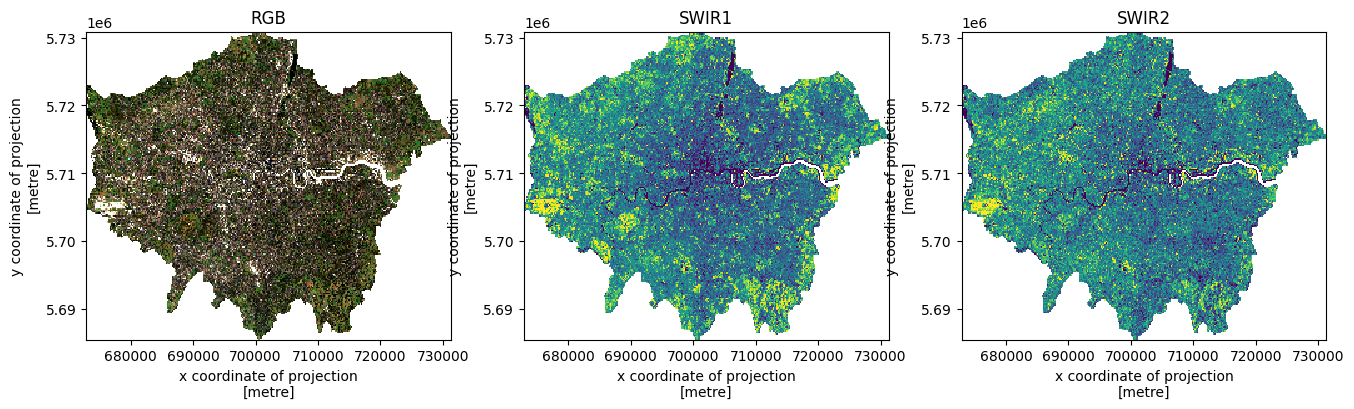

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 4))

rgb.sel(band=["red", "green", "blue"]).plot.imshow(ax=axes[0], robust=True)
swir.sel(band="swir1").plot.imshow(
    ax=axes[1], cmap="viridis", robust=True, add_colorbar=False
)
swir.sel(band="swir2").plot.imshow(
    ax=axes[2], cmap="viridis", robust=True, add_colorbar=False
)

axes[0].set_title("RGB")
axes[1].set_title("SWIR1")
axes[2].set_title("SWIR2")

In [ ]:
def calculate_endisi(rgb: xr.Dataset, swir: xr.Dataset):  # noqa: ANN201
    # Enhanced Normalised Difference Impervious Surfaces Index, Chen et al. 2019
    def mndwi(rgb, swir):
        return (rgb.sel(band="green") - swir.sel(band="swir1")) / (
            rgb.sel(band="green") + swir.sel(band="swir1")
        )

    def swir_diff(swir):
        return swir.sel(band="swir1") / swir.sel(band="swir2")

    def alpha(rgb, swir):
        return (2 * (np.mean(rgb.sel(band="blue")))) / (
            np.mean(swir_diff(swir)) + np.mean(mndwi(rgb, swir) ** 2)
        )

    m = mndwi(rgb, swir)
    s = swir_diff(swir)
    a = alpha(rgb, swir)

    return (rgb.sel(band="blue") - (a) * (s + m**2)) / (
        rgb.sel(band="blue") + (a) * (s + m**2)
    )


endisi = calculate_endisi(rgb, swir)

In [ ]:
fig, axes = plt.subplots(figsize=(15, 10))

kwargs = {
    "vmin": -0.75,
    "vmax": 0.75,
    "cmap": "RdBu",
    "robust": True,
    "add_colorbar": False,
}

endisi.plot(ax=axes, **kwargs)

london.boundary.plot(ax=axes, color="black")
axes.set_axis_off()

axes.set_title("ENDISI - 2023")

sm = plt.cm.ScalarMappable(
    cmap=kwargs["cmap"],
    norm=plt.Normalize(vmin=kwargs["vmin"], vmax=kwargs["vmax"]),
)
sm.set_array([])
cb2 = plt.colorbar(
    sm,
    cax=fig.add_axes([0.95, 0.4, 0.03, 0.2]),
    orientation="vertical",
    ticks=[-0.75, 0, 0.75],
    fraction=0.5,
    pad=0.5,
)

cb2.ax.tick_params(color="none", labelsize=12)
cb2.set_label(
    "",
    fontsize=18,
    fontweight="bold",
)

In [ ]:
endisi_no_na = endisi.fillna(endisi.mean().values)

threshold = threshold_otsu(endisi_no_na.values)

print(f"ENDISI value: {round(threshold, 2)}")

In [ ]:
fig, axes = plt.subplots(figsize=(10, 3))

kwargs = {"bins": 1000, "range": (-1, 1), "facecolor": "gray"}

endisi.plot.hist(ax=axes, **kwargs)

axes.axvline(threshold, color="red", linestyle="--", linewidth=0.5)

axes.set_title("ENDISI Histogram: 2023")

In [ ]:
urban_area_2023 = (endisi_no_na > threshold).astype(int)
urban_area_2023 = urban_area_2023.where(urban_area_2023 != 0, np.nan)

In [ ]:
fig, axes = plt.subplots(figsize=(10, 10))

kwargs = {
    "robust": True,
    "add_colorbar": False,
}

urban_area_2023.plot(ax=axes, **kwargs)

ctx.add_basemap(axes, crs=urban_area_2023.rio.crs.to_string())

axes.set_axis_off()

axes.set_title("Proxy urban area (2023)")